ML Model learns patterns by its own


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [4]:
emails = [
    "Free Money",
    "Get a chance to win $1000",
    "Click on this link to get rewards",
    "Earn Money for free",
    "Can you review the documents",
    "URGENT! You account will be closed",
    "Click on this link to reset your password",
    "Below is the OTP for your registration"
]
labels = [1, 1, 1, 1, 0, 1, 0, 0] #1 spam, 0 not spam

In [17]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(emails)
model = MultinomialNB()
model.fit(X, labels)
learned_words = vectorizer.get_feature_names_out()
print(f"Learned words: {learned_words}")
new_email = [" you are certified as Gen AI leader"]
new_email_vector = vectorizer.transform(new_email)
prediction = model.predict(new_email_vector)
print(f"Spam: {bool (prediction[0])}")

Learned words: ['1000' 'account' 'be' 'below' 'can' 'chance' 'click' 'closed' 'documents'
 'earn' 'for' 'free' 'get' 'is' 'link' 'money' 'on' 'otp' 'password'
 'registration' 'reset' 'review' 'rewards' 'the' 'this' 'to' 'urgent'
 'will' 'win' 'you' 'your']
Spam: True


Traditional ML Method

In [13]:
def is_spam_email(email):
  email_lower = email.lower()
  #Rule 1
  for word in spam_words:
    if word in email_lower:
      return True
    #Rule 2
  if(email.count('!') > 3):
    return True
    #Rule 3
  if(word.isupper()):
    return True
  return False

spam_words = ["free", "winnner", "congratulations", "free money"]

new_email = "Congratulations You just won a reward, Claim it."

print(f"Email: {new_email} \n Spam: {is_spam_email(new_email)}")

Email: Congratulations You just won a reward, Claim it. 
 Spam: True


Supervised Learning

In [25]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

print("Supervised Learning:  House Prediction ")

sqft = np.array([[1000], [1500], [2000], [2500], [3000]])
prices = np.array([200000, 280000, 350000, 420000, 500000])

model = LinearRegression()
model.fit(sqft, prices)
new_sqft = np.array([4000])

prediction = model.predict(new_sqft.reshape(-1,1))
print(f"Predicted price for new house with {new_sqft[0]} is {prediction[0]}")

Supervised Learning:  House Prediction 
Predicted price for new house with 4000 is 646000.0


Unsupervised Learning

In [28]:
print("Unsupervised  learning: Customer Clustering")

customers = np.array([
    [25, 30000],   # age, income
    [35, 50000],
    [45, 80000],
    [22, 25000],
    [55, 100000],
    [28, 35000],
])

kmeans = KMeans(n_clusters=2)
clusters = kmeans.fit_predict(customers)
print(f"cluster labels: {kmeans.labels_}")
print(f"cluster centers: {kmeans.cluster_centers_}")
print(f"cluster assignments: {clusters}")

Unsupervised  learning: Customer Clustering
cluster labels: [1 1 0 1 0 1]
cluster centers: [[5.00e+01 9.00e+04]
 [2.75e+01 3.50e+04]]
cluster assignments: [1 1 0 1 0 1]


Linear Regression - Closed Form and Gradient Descent

In [6]:
import numpy as np
np.random.seed(56)
X = np.random.randn(100,1)
y = 3 * np.reshape(X, -1) + 2 + np.random.randn(100) * 0.5
X_bais = np.c_[np.ones(len(X)), X]

w_closed = np.linalg.inv(X_bais.T @ X_bais) @ X_bais.T @ y
print(f"Closed form: {w_closed}")
print(f"Closed Form: bais = {w_closed[0]:.4f} slope = {w_closed[1]:.4f} ")


print("------Gradient Descent----------")
w_gd = np.zeros(2)
lr = 0.1

for epoch in range(200):
  y_pred = X_bais @ w_gd
  loss = np.mean((y - y_pred)**2)
  grad = -(2/len(X)) * X_bais.T @ (y - y_pred)
  w_gd -= lr * grad

print(f"Gradient Descent: bais = {w_gd[0]:.4f} slope = {w_gd[1]:.4f}")
print(f"Gradient Descent: Loss = {loss:.4f}")
print(f"True values: bais=2, slope=3")

Closed form: [1.98443361 3.01290828]
Closed Form: bais = 1.9844 slope = 3.0129 
------Gradient Descent----------
Gradient Descent: bais = 1.9844 slope = 3.0129
Gradient Descent: Loss = 0.2508
True values: bais=2, slope=3


Linear Regression- practical way

Training Score: 0.9945
Test Score: 0.9940
Model coefficients: [ 1.91622957 -1.44302176  0.52381985]
Model intercept: -0.4218


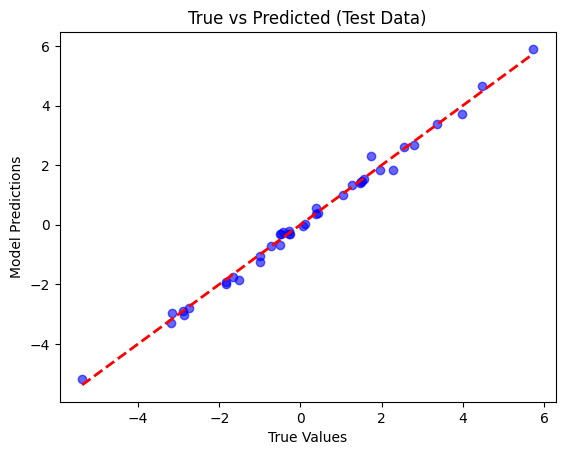

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(56)
X = np.random.randn(200,3)
y = 2*X[:,0] - 1.5*X[:,1] + 0.5*X[:,2] + np.random.randn(200) * 0.2

X_train , X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)

print(f"Training Score: {train_score:.4f}")
print(f"Test Score: {test_score:.4f}")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_:.4f}")

import matplotlib.pyplot as plt

# Get the model's predictions for the test data
y_pred = model.predict(X_test_scaled)

# Plot True answers vs Model's answers
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)

# Draw a perfect diagonal line. If the model is perfect,
# all blue dots will fall exactly on this red line.
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel("True Values")
plt.ylabel("Model Predictions")
plt.title("True vs Predicted (Test Data)")
plt.show()

Logistic Regression with sigmoid and cross entropy

In [3]:
import numpy as np

def sigmoid(z):
  return 1 / (1 + np.exp(-np.clip(z, -700, 700)))

np.random.seed(42)
X = np.random.randn(100,2)
y = (X[:,0] + X[:,1] > 0).astype(int)

X_bais = np.c_[np.ones(len(X)), X]
w = np.zeros(3)
lr, epochs = 0.1, 2000

for epoch in range(epochs):
  z = X_bais @ w
  y_pred = sigmoid(z)
  loss = -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
  grad = -(1/len(X)) * X_bais.T @ (y - y_pred)
  w -= lr * grad

  if epoch % 50 == 0:
        acc = np.mean((y_pred >= 0.5) == y)
        print(f"Epoch {epoch}: Loss={loss:.4f}, Accuracy={acc:.1%}")

print(f"\nFinal weights: bias={w[0]:.3f}, w1={w[1]:.3f}, w2={w[2]:.3f}")

Epoch 0: Loss=0.6931, Accuracy=44.0%
Epoch 50: Loss=0.3570, Accuracy=96.0%
Epoch 100: Loss=0.2733, Accuracy=97.0%
Epoch 150: Loss=0.2334, Accuracy=98.0%
Epoch 200: Loss=0.2088, Accuracy=98.0%
Epoch 250: Loss=0.1918, Accuracy=99.0%
Epoch 300: Loss=0.1790, Accuracy=99.0%
Epoch 350: Loss=0.1689, Accuracy=99.0%
Epoch 400: Loss=0.1607, Accuracy=99.0%
Epoch 450: Loss=0.1538, Accuracy=99.0%
Epoch 500: Loss=0.1479, Accuracy=99.0%
Epoch 550: Loss=0.1428, Accuracy=99.0%
Epoch 600: Loss=0.1383, Accuracy=99.0%
Epoch 650: Loss=0.1343, Accuracy=99.0%
Epoch 700: Loss=0.1307, Accuracy=99.0%
Epoch 750: Loss=0.1274, Accuracy=99.0%
Epoch 800: Loss=0.1245, Accuracy=99.0%
Epoch 850: Loss=0.1217, Accuracy=99.0%
Epoch 900: Loss=0.1192, Accuracy=99.0%
Epoch 950: Loss=0.1169, Accuracy=99.0%
Epoch 1000: Loss=0.1147, Accuracy=99.0%
Epoch 1050: Loss=0.1127, Accuracy=99.0%
Epoch 1100: Loss=0.1108, Accuracy=99.0%
Epoch 1150: Loss=0.1090, Accuracy=99.0%
Epoch 1200: Loss=0.1073, Accuracy=99.0%
Epoch 1250: Loss=0.1058

Practical Usage

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np

np.random.seed(43)
X = np.random.randn(200,3)
y = (X[:,0] + 0.5 * X[:,1] + 0.2 * X[:,2] + np.random.randn(200) * 0.2 > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


print("Get Predictions")
probs = model.predict_proba(X_test)[:,1]
print(f"Probabilities: {probs}")

for threshold in [0.3, 0.5, 0.7]:
  preds = (probs >= threshold).astype(int)
  print(f"\nThreshold: {threshold}")
  print(f"Prediction: {precision_score(y_test,preds):.2%}")
  print(f"Recall: {recall_score(y_test, preds):.2%}")
  print(f"Accuracy: {accuracy_score(y_test, preds):.2%}")


Accuracy: 0.9250
Precision: 0.9583
Recall: 0.9200
Get Predictions
Probabilities: [0.87591687 0.02202901 0.54658809 0.9999981  0.84053177 0.97876262
 0.23807391 0.99946922 0.26880516 0.9747292  0.99971013 0.98909614
 0.00702523 0.9634941  0.95001881 0.00326771 0.12220305 0.02077577
 0.03922314 0.97249986 0.77726163 0.3816139  0.49367038 0.76241262
 0.90472258 0.01411636 0.93602875 0.99893125 0.93332335 0.02257236
 0.89926075 0.84148702 0.29123717 0.13058616 0.83469667 0.99690643
 0.65782468 0.0403134  0.01176475 0.99888224]

Threshold: 0.3
Prediction: 92.31%
Recall: 96.00%
Accuracy: 92.50%

Threshold: 0.5
Prediction: 95.83%
Recall: 92.00%
Accuracy: 92.50%

Threshold: 0.7
Prediction: 100.00%
Recall: 88.00%
Accuracy: 92.50%
